# MC62 — LEAR C-shaped Dipole — `02_staircase_without_shims` — Rotating Coil Analysis

**Magnet**: MC62 (red bulk C-shaped dipole)
**Machine**: LEAR antiproton decelerator, CERN
**Test**: `02_staircase_without_shims` — full hysteresis staircase (2026-02-12)
**Current cycle**: 0 → +200 → 0 → −200 → 0 A in 20 A steps (41 plateaus)
**PCBs**: Integral (R45, long coil) and Central (DQ, small coil), 350 turns/plateau at −60 rpm

---
**Note on the large b2**: C-shaped dipoles have inherent left-right asymmetry (open gap
on one side, iron yoke on the other). This breaks the mid-plane symmetry that an H-dipole
would have, producing a systematic quadrupole gradient (b2) across the aperture.

## 1. Configuration

Adjust parameters below, then **Run All**.

In [1]:
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────
BASE_DIR    = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer\measurements\2026_02_11_MC62")
TEST_DIR    = BASE_DIR / "02_staircase_without_shims" / "20260212_075344_staircase_without_shims_MC62"
RUN_DIR     = TEST_DIR / "20260212_100000_MC62"
KN_DIR      = BASE_DIR / "Kn values"

KN_INTEGRAL = KN_DIR / "Kn_R45_PCB_N1_0001_A_AC.txt"       # integral (long) PCB
KN_CENTRAL  = KN_DIR / "Kn_DQ_5_18_7_250_47x50_0001_A_AC.txt"  # central (small) PCB

# ── Magnet & coil parameters ──────────────────────────────────────────
MAGNET_ORDER     = 1        # dipole
R_REF            = 0.033    # reference radius [m]  (2/3 of 50 mm half-gap)
SAMPLES_PER_TURN = 1024     # encoder resolution

# ── Averaging & selection ─────────────────────────────────────────────
N_LAST_TURNS = 170          # average last 170 turns (skip first 180 ≈ 10×tau for settling)

# ── Sign convention ───────────────────────────────────────────────────
FLIP_FIELD_SIGN = True      # True = flip sign of all Tesla columns

# ── Pipeline options ──────────────────────────────────────────────────
# dit (di/dt correction) omitted: only relevant for per-turn parity
# against FFMM C++ on streaming data with current ramps.
OPTIONS    = ("dri", "rot", "cel", "fed")
DRIFT_MODE = "legacy"
MIN_B1_T   = 1e-6           # warm dipole: lower threshold for ok_main

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%matplotlib widget

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    process_kn_pipeline,
    build_harmonic_rows,
    discover_runs,
    plateau_summary,
    plot_hysteresis,
    diagnose_cel_fed,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

## 2. Load Kn Calibration

External Kn files (same calibration used for all MC62 tests).
The in-test Kn files now match the external ones (verified).

In [3]:
kn_integral = load_segment_kn_txt(str(KN_INTEGRAL))
kn_central  = load_segment_kn_txt(str(KN_CENTRAL))

for lbl, kn in [("Integral (R45)", kn_integral), ("Central (DQ)", kn_central)]:
    k1_abs = abs(kn.kn_abs[0])
    k1_cmp = abs(kn.kn_cmp[0])
    supp = k1_abs / max(k1_cmp, 1e-30)
    print(f"{lbl:20s}: {len(kn.orders):2d} harmonics, "
          f"k1_abs = {k1_abs:.6f}, suppression = {supp:.0f}x")

Integral (R45)      : 30 harmonics, k1_abs = 1.447495, suppression = 12924x
Central (DQ)        : 15 harmonics, k1_abs = 0.031959, suppression = 2302922349194870x


## 3. Discover and Load Raw Data

Each run is a plateau at fixed current.  Raw data columns: `[time, ch1, ch2, I_DCCT]`.
41 runs, 350 turns each, 20 A staircase: 0→+200→0→−200→0 A.
Channel detection uses `robust_range` on the highest-current run.

In [4]:
Ns = SAMPLES_PER_TURN

runs_integral = discover_runs(RUN_DIR, "Integral")
runs_central  = discover_runs(RUN_DIR, "Central")

print(f"Found {len(runs_integral)} integral runs, "
      f"{len(runs_central)} central runs")
print(f"Turns per run: {np.loadtxt(runs_integral[0]['file']).shape[0] // Ns}\n")
for r in runs_integral:
    print(f"  Run {r['run_id']:02d}: I = {r['I_nom']:+8.2f} A")

Found 41 integral runs, 41 central runs
Turns per run: 350

  Run 00: I =    +0.00 A
  Run 01: I =   +20.00 A
  Run 02: I =   +40.00 A
  Run 03: I =   +60.00 A
  Run 04: I =   +80.00 A
  Run 05: I =  +100.00 A
  Run 06: I =  +120.00 A
  Run 07: I =  +140.00 A
  Run 08: I =  +160.00 A
  Run 09: I =  +180.00 A
  Run 10: I =  +200.00 A
  Run 11: I =  +180.00 A
  Run 12: I =  +160.00 A
  Run 13: I =  +140.00 A
  Run 14: I =  +120.00 A
  Run 15: I =  +100.00 A
  Run 16: I =   +80.00 A
  Run 17: I =   +60.00 A
  Run 18: I =   +40.00 A
  Run 19: I =   +20.00 A
  Run 20: I =    +0.00 A
  Run 21: I =   -20.00 A
  Run 22: I =   -40.00 A
  Run 23: I =   -60.00 A
  Run 24: I =   -80.00 A
  Run 25: I =  -100.00 A
  Run 26: I =  -120.00 A
  Run 27: I =  -140.00 A
  Run 28: I =  -160.00 A
  Run 29: I =  -180.00 A
  Run 30: I =  -200.00 A
  Run 31: I =  -180.00 A
  Run 32: I =  -160.00 A
  Run 33: I =  -140.00 A
  Run 34: I =  -120.00 A
  Run 35: I =  -100.00 A
  Run 36: I =   -80.00 A
  Run 37: I =  

## 3b. Current Profile and Turn Map

Load time and DCCT current from **all** run files to build the full
measurement timeline.  Each turn is drawn as a coloured bar at its
mean current level.

In [5]:
# ── Collect per-sample time & current from all runs ────────────────────
t_all_samples = []
I_all_samples = []
turn_info = []

for run_info in runs_integral:
    raw = np.loadtxt(run_info["file"])
    n_turns = raw.shape[0] // Ns
    raw = raw[: n_turns * Ns]

    t_samp = raw[:, 0]
    I_samp = raw[:, 3]
    t_all_samples.append(t_samp)
    I_all_samples.append(I_samp)

    t_2d = t_samp.reshape(n_turns, Ns)
    I_2d = I_samp.reshape(n_turns, Ns)
    for ti in range(n_turns):
        turn_info.append({
            "t_start": t_2d[ti, 0],
            "t_end":   t_2d[ti, -1],
            "I_mean":  I_2d[ti].mean(),
            "run_id":  run_info["run_id"],
            "I_nom":   run_info["I_nom"],
            "turn_in_run": ti,
        })

t_all_samples = np.concatenate(t_all_samples)
I_all_samples = np.concatenate(I_all_samples)
df_turns = pd.DataFrame(turn_info)

print(f"Timeline: {t_all_samples[0]:.1f} - {t_all_samples[-1]:.1f} s  "
      f"({len(df_turns)} turns across {df_turns['run_id'].nunique()} runs)")

Timeline: 0.0 - 26123.6 s  (14351 turns across 41 runs)


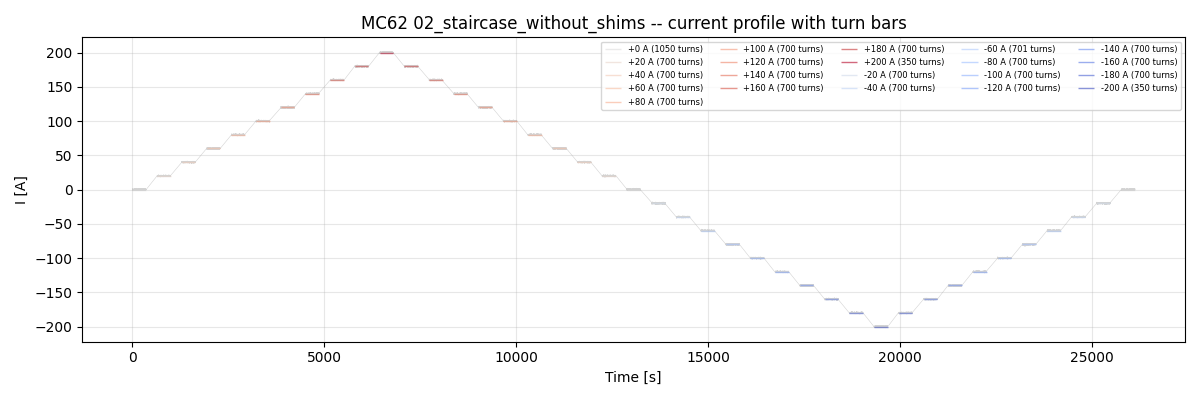

In [6]:
# ── Current profile with turn-bar overlay ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

# Background: per-sample current (subsample for speed)
step = max(1, len(t_all_samples) // 80000)
ax.plot(t_all_samples[::step], I_all_samples[::step],
        linewidth=0.4, color="lightgrey", zorder=0)

# Colour palette per nominal current level
unique_I = sorted(df_turns["I_nom"].unique())
cmap = plt.cm.coolwarm
norm_c = plt.Normalize(min(unique_I), max(unique_I))
plateau_colors = {I: cmap(norm_c(I)) for I in unique_I}

# Draw each turn as a horizontal bar at its mean current
drawn_labels = set()
for _, row in df_turns.iterrows():
    I_nom = row["I_nom"]
    col = plateau_colors[I_nom]
    kw = {}
    lbl_key = f"{I_nom:+.0f} A"
    if lbl_key not in drawn_labels:
        n_at = int((df_turns["I_nom"] == I_nom).sum())
        kw["label"] = f"{lbl_key} ({n_at} turns)"
        drawn_labels.add(lbl_key)
    ax.plot([row["t_start"], row["t_end"]],
            [row["I_mean"], row["I_mean"]],
            linewidth=1.0, color=col, alpha=0.6,
            solid_capstyle="butt", zorder=2, **kw)

ax.set_xlabel("Time [s]")
ax.set_ylabel("I [A]")
ax.set_title("MC62 02_staircase_without_shims -- current profile with turn bars")
ax.legend(loc="upper right", fontsize=6, ncol=5)
fig.tight_layout()
plt.show()

## Turn Classification Map

Every recorded turn color-coded: green = used for computation (last N turns
per plateau), gold = settling / excluded from average. Only plateau data is
recorded in this run-based measurement (no ramp or transition turns available).

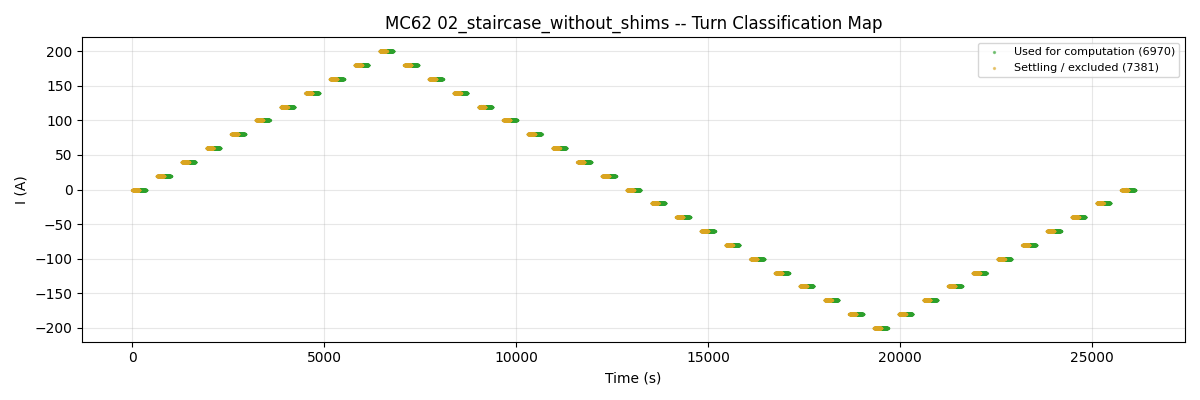


Turn classification: 6970 used + 7381 settling = 14351 total

 Run    I_nom  Total   Used  Settling
----------------------------------------
   0       +0    350    170       180
   1      +20    350    170       180
   2      +40    350    170       180
   3      +60    350    170       180
   4      +80    350    170       180
   5     +100    350    170       180
   6     +120    350    170       180
   7     +140    350    170       180
   8     +160    350    170       180
   9     +180    350    170       180
  10     +200    350    170       180
  11     +180    350    170       180
  12     +160    350    170       180
  13     +140    350    170       180
  14     +120    350    170       180
  15     +100    350    170       180
  16      +80    350    170       180
  17      +60    350    170       180
  18      +40    350    170       180
  19      +20    350    170       180
  20       +0    350    170       180
  21      -20    350    170       180
  22      -40    350  

In [7]:
# ── Classify turns: used vs settling ───────────────────────────────────
_n_in_run = df_turns.groupby("run_id")["turn_in_run"].transform("max") + 1
_cutoff = _n_in_run - N_LAST_TURNS
_is_used = df_turns["turn_in_run"].values >= _cutoff.values
_t_mid = (df_turns["t_start"].values + df_turns["t_end"].values) / 2
_n_used = int(_is_used.sum())
_n_settling = int((~_is_used).sum())

fig, ax = plt.subplots(figsize=(12, 4))
for flag, color, label in [
    (True,  "tab:green", f"Used for computation ({_n_used})"),
    (False, "goldenrod", f"Settling / excluded ({_n_settling})"),
]:
    mask = _is_used == flag
    ax.scatter(_t_mid[mask], df_turns["I_mean"].values[mask], s=2, alpha=0.5,
               color=color, label=label, zorder=2)

ax.set_xlabel("Time (s)")
ax.set_ylabel("I (A)")
ax.set_title("MC62 02_staircase_without_shims -- Turn Classification Map")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# ── Per-plateau summary ───────────────────────────────────────────────
print(f"\nTurn classification: {_n_used} used + {_n_settling} settling "
      f"= {len(df_turns)} total")
print(f"\n{'Run':>4s} {'I_nom':>8s} {'Total':>6s} {'Used':>6s} {'Settling':>9s}")
print("-" * 40)
for _rid in sorted(df_turns["run_id"].unique()):
    _rmask = df_turns["run_id"].values == _rid
    _I = df_turns.loc[_rmask, "I_nom"].iloc[0]
    _nt = int(_rmask.sum())
    _nu = int(_is_used[_rmask].sum())
    print(f"{_rid:4d} {_I:+8.0f} {_nt:6d} {_nu:6d} {_nt - _nu:9d}")

## 3c. cel/fed Safety Diagnostic

Run `diagnose_cel_fed()` on the highest-|I| run for each PCB to check
whether the centre-location + feeddown correction is safe for this data.
For dipoles, cel uses compensated harmonics n=10,11 which can be pure
noise at low SNR.  See `correction_options_reference.md` for background.

In [8]:
def _cel_fed_check(runs, kn, label):
    """Run cel/fed diagnostic on the highest-|I| run."""
    peak = max(runs, key=lambda r: abs(r["I_nom"]))
    raw = np.loadtxt(peak["file"])
    nt = raw.shape[0] // Ns
    raw = raw[:nt * Ns]
    rr1, rr2 = robust_range(raw[:, 1]), robust_range(raw[:, 2])
    sw = rr2 > rr1
    shape = (nt, Ns)
    t = raw[:, 0].reshape(shape)
    fa = raw[:, 2 if sw else 1].reshape(shape)
    fc = raw[:, 1 if sw else 2].reshape(shape)
    Ia = raw[:, 3].reshape(shape)
    d = diagnose_cel_fed(fa, fc, t, Ia, kn=kn, r_ref=R_REF,
                         magnet_order=MAGNET_ORDER)
    print(f"[{label}] Run {peak['run_id']} (I={peak['I_nom']:+.0f} A): "
          f"{d.recommendation}")
    print(f"  {d.reason}")
    Bd = np.max(np.abs(d.B_main_with_fed - d.B_main_without_fed))
    print(f"  B_main max |diff|: {Bd:.4e} T\n")
    return d

diag_int = _cel_fed_check(runs_integral, kn_integral, "Integral")
diag_cen = _cel_fed_check(runs_central, kn_central, "Central")

# Act on diagnostic: disable cel/fed if either segment is unsafe
if diag_int.recommendation == "UNSAFE" or diag_cen.recommendation == "UNSAFE":
    OPTIONS = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
    print(f"\ncel/fed disabled, OPTIONS = {OPTIONS}")
else:
    print(f"\ncel/fed safe, keeping OPTIONS = {OPTIONS}")


[Integral] Run 10 (I=+200 A): UNSAFE
  350/350 turns (100%) have |zR| > 0.0100 (median 0.1206, max 0.2080). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 2.8467e-05 T



[Central] Run 10 (I=+200 A): UNSAFE
  342/350 turns (98%) have |zR| > 0.0100 (median 0.0584, max 0.5667). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 5.7793e-05 T


cel/fed disabled, OPTIONS = ('dri', 'rot')


## 4. Process All Runs Through Kn Pipeline

Pipeline follows the Bottura standard (MTA-IN-97-007): drift → DFT → Kn →
centre location → feed-down → rotation → normalization → merge.

- **Integral**: `abs_upto_m_cmp_above` (B1 from absolute, n>1 from compensated)
- **Central**: `abs_all` (all from absolute — compensated SNR ≈ 3, unusable)

In [9]:
def load_and_process_runs(runs, kn, label, merge_mode="abs_upto_m_cmp_above"):
    all_rows = []

    # Channel detection from highest-current run
    peak_run = max(runs, key=lambda r: abs(r["I_nom"]))
    raw_peak = np.loadtxt(peak_run["file"])
    rr1 = robust_range(raw_peak[:, 1])
    rr2 = robust_range(raw_peak[:, 2])
    swap = rr2 > rr1
    print(f"[{label}] col1 range={rr1:.3e}, col2 range={rr2:.3e}"
          f"  ->  {'SWAP' if swap else 'no swap'}"
          f"  |  merge: {merge_mode}")

    # Hysteresis branch direction
    I_noms = [r["I_nom"] for r in runs]
    branches = ["ascending"]
    for i in range(1, len(I_noms)):
        if I_noms[i] > I_noms[i - 1]:
            branches.append("ascending")
        elif I_noms[i] < I_noms[i - 1]:
            branches.append("descending")
        else:
            branches.append(branches[-1])

    for ri, run_info in enumerate(runs):
        raw = np.loadtxt(run_info["file"])
        n_turns = raw.shape[0] // Ns
        raw = raw[: n_turns * Ns]

        t_turns  = raw[:, 0].reshape(n_turns, Ns)
        ch1      = raw[:, 1].reshape(n_turns, Ns)
        ch2      = raw[:, 2].reshape(n_turns, Ns)
        flux_abs = ch2 if swap else ch1
        flux_cmp = ch1 if swap else ch2
        # Column 3 is DCCT current (already in Amperes)
        I_turns  = raw[:, 3].reshape(n_turns, Ns)

        try:
            result, C_merged, C_units, ok_main = process_kn_pipeline(
                flux_abs, flux_cmp, t_turns, I_turns, kn, R_REF,
                MAGNET_ORDER,
                options=OPTIONS, drift_mode=DRIFT_MODE,
                min_b1_T=MIN_B1_T,
                merge_mode=merge_mode,
            )
            extra = [{"run_id": run_info["run_id"],
                       "I_nom": run_info["I_nom"],
                       "branch": branches[ri],
                       "turn_in_run": t,
                       "pcb": label}
                      for t in range(n_turns)]
            rows = build_harmonic_rows(
                result, C_merged, C_units, ok_main,
                MAGNET_ORDER, extra)
            all_rows.extend(rows)
            n_ok = int(sum(ok_main))
            I_actual = I_turns.mean()
            print(f"  Run {run_info['run_id']:02d} "
                  f"(I_nom={run_info['I_nom']:+7.1f} A, "
                  f"I_meas={I_actual:+7.1f} A): "
                  f"{n_turns} turns, {n_ok} ok")
        except Exception as e:
            print(f"  Run {run_info['run_id']:02d} "
                  f"({run_info['I_nom']:+7.1f} A): FAILED - {e}")

    return pd.DataFrame(all_rows)

print("Processing Integral PCB (R45)...")
df_int = load_and_process_runs(runs_integral, kn_integral, "Integral")
print(f"\nProcessing Central PCB (DQ) -- merge_mode='abs_all' (cmp SNR too low)...")
df_cen = load_and_process_runs(runs_central, kn_central, "Central",
                               merge_mode="abs_all")

# ── Sign convention ────────────────
if FLIP_FIELD_SIGN:
    for _df in [df_int, df_cen]:
        abs_cols = [c for c in _df.columns if c.endswith("_T")]
        _df[abs_cols] *= -1
    print("\n[Sign flip applied to Tesla columns]")

print(f"\nIntegral: {len(df_int)} rows  |  Central: {len(df_cen)} rows")

Processing Integral PCB (R45)...


[Integral] col1 range=4.060e-03, col2 range=5.434e-05  ->  no swap  |  merge: abs_upto_m_cmp_above


  Run 00 (I_nom=   +0.0 A, I_meas=   +0.0 A): 350 turns, 350 ok


  Run 01 (I_nom=  +20.0 A, I_meas=  +20.0 A): 350 turns, 350 ok


  Run 02 (I_nom=  +40.0 A, I_meas=  +40.0 A): 350 turns, 350 ok


...

  Run 36 (I_nom=  -80.0 A, I_meas=  -80.0 A): 350 turns, 350 ok


  Run 37 (I_nom=  -60.0 A, I_meas=  -60.0 A): 350 turns, 350 ok


  Run 38 (I_nom=  -40.0 A, I_meas=  -40.0 A): 350 turns, 350 ok


  Run 39 (I_nom=  -20.0 A, I_meas=  -20.0 A): 350 turns, 350 ok


  Run 40 (I_nom=   +0.0 A, I_meas=   +0.0 A): 350 turns, 350 ok

[Sign flip applied to Tesla columns]

Integral: 14351 rows  |  Central: 14351 rows


## 5. Plateau Quality & Averaging

Select the **last N turns** per plateau (to let eddy currents settle).
Flag plateaus as *good* or *bad* based on `ok_main`.

In [10]:
summ_int = plateau_summary(df_int, N_LAST_TURNS)
summ_cen = plateau_summary(df_cen, N_LAST_TURNS)

cols_show = ["run_id", "I_nom", "branch", "n_ok",
             "B1_mean", "B1_std", "quality"]
print("=== Integral PCB (R45) ===")
print(summ_int[cols_show].to_string(index=False, float_format="%.6f"))
print(f"\n=== Central PCB (DQ) ===")
print(summ_cen[cols_show].to_string(index=False, float_format="%.6f"))

=== Integral PCB (R45) ===
 run_id       I_nom     branch  n_ok   B1_mean   B1_std quality
      0    0.000000  ascending   170 -0.000263 0.000004    good
      1   20.000000  ascending   170  0.025489 0.000007    good
      2   40.000000  ascending   170  0.051311 0.000010    good
      3   60.000000  ascending   170  0.077131 0.000012    good
      4   80.000000  ascending   170  0.102920 0.000012    good
      5  100.000000  ascending   170  0.128640 0.000011    good
      6  120.000000  ascending   170  0.154206 0.000008    good
      7  140.000000  ascending   170  0.178683 0.000002    good
      8  160.000000  ascending   170  0.198255 0.000001    good
      9  180.000000  ascending   170  0.213634 0.000001    good
     10  200.000000  ascending   170  0.226344 0.000002    good
     11  180.000000 descending   170  0.214170 0.000001    good
     12  160.000000 descending   170  0.199093 0.000001    good
     13  140.000000 descending   170  0.179507 0.000001    good
     14  120.

## 6. Eddy-Current Settling — B1 vs Turn Number

Turn-by-turn evolution within each plateau.  With 350 turns per run,
only the first 30 turns are shown to highlight the settling region.

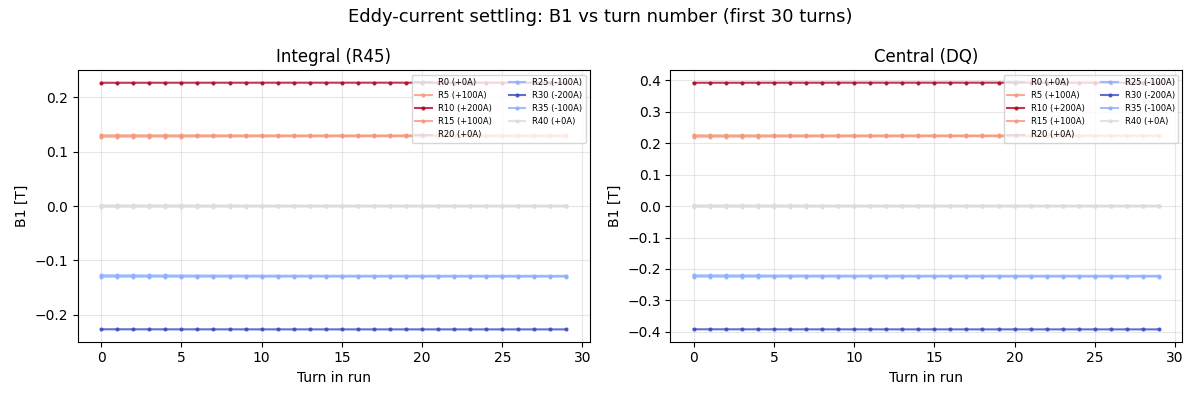

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, label in [(axes[0], df_int, "Integral (R45)"),
                       (axes[1], df_cen, "Central (DQ)")]:
    cmap = plt.cm.coolwarm
    all_runs = sorted(df["run_id"].unique())
    I_min = df["I_nom"].min()
    I_max = df["I_nom"].max()
    norm = plt.Normalize(I_min, I_max)

    # Show a subset of runs for clarity
    show_runs = [0, 5, 10, 15, 20, 25, 30, 35, 40]
    for run_id in show_runs:
        rdf = df[df["run_id"] == run_id].sort_values("turn_in_run")
        ok = rdf["ok_main"].astype(bool)
        if not ok.any():
            continue
        I_nom = rdf["I_nom"].iloc[0]
        color = cmap(norm(I_nom))
        # Show first 30 turns only
        first30 = rdf[rdf["turn_in_run"] < 30]
        ok30 = first30["ok_main"].astype(bool)
        if ok30.any():
            ax.plot(first30.loc[ok30, "turn_in_run"],
                    first30.loc[ok30, "B1_T"],
                    "o-", ms=2, color=color, alpha=0.8,
                    label=f"R{run_id} ({I_nom:+.0f}A)")

    ax.set_xlabel("Turn in run")
    ax.set_ylabel("B1 [T]")
    ax.set_title(label)
    ax.legend(fontsize=6, ncol=2)

fig.suptitle("Eddy-current settling: B1 vs turn number (first 30 turns)", fontsize=13)
fig.tight_layout()
plt.show()

## 7. B1 (Main Dipole Field) vs Current — Hysteresis

Averaged over last N turns.  **Blue** = ascending, **Red** = descending.
Line shading: light/thin = start of measurement, dark/thick = end.

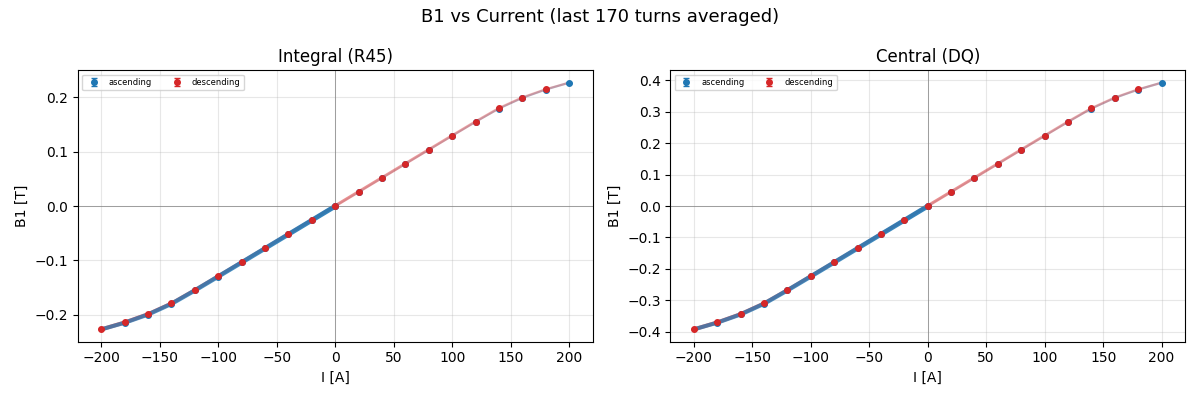

In [12]:
branch_colors = {"ascending": "tab:blue", "descending": "tab:red"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "B1_mean", "B1_std")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("B1 [T]")
    ax.set_title(label)
    ax.legend(fontsize=6, ncol=2)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)

fig.suptitle(f"B1 vs Current (last {N_LAST_TURNS} turns averaged)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 8. b2 (Quadrupole) vs Current

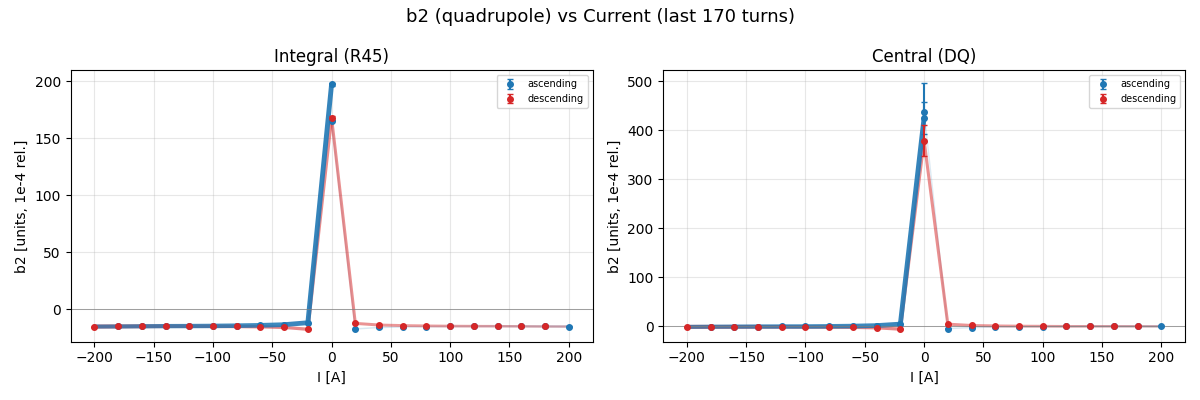

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "b2_units_mean", "b2_units_std")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("b2 [units, 1e-4 rel.]")
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle(f"b2 (quadrupole) vs Current (last {N_LAST_TURNS} turns)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 9. b3 (Sextupole) vs Current

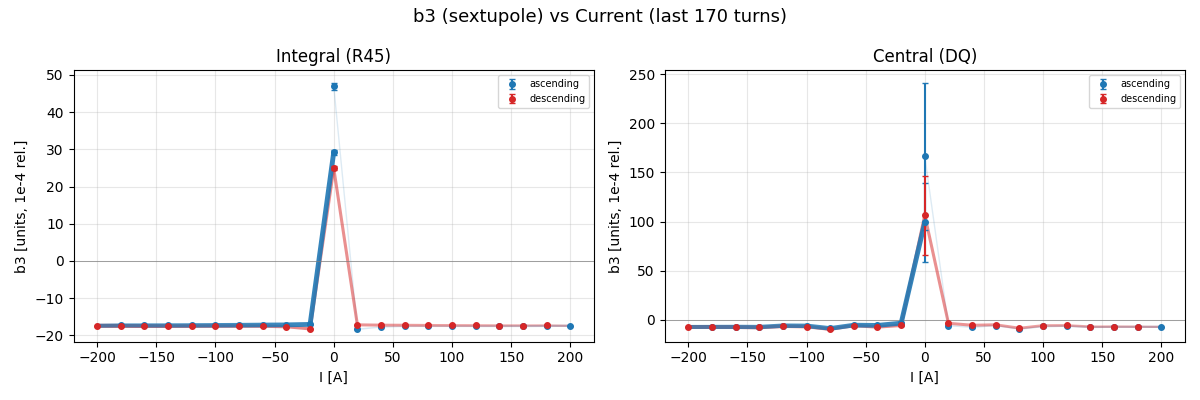

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "b3_units_mean", "b3_units_std")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("b3 [units, 1e-4 rel.]")
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle(f"b3 (sextupole) vs Current (last {N_LAST_TURNS} turns)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 10. Transfer Function  B1 / I  vs I

Excludes 0 A runs (undefined).  Saturation appears as a drop in TF at
high |I|.  The staircase gives a detailed TF curve vs current.

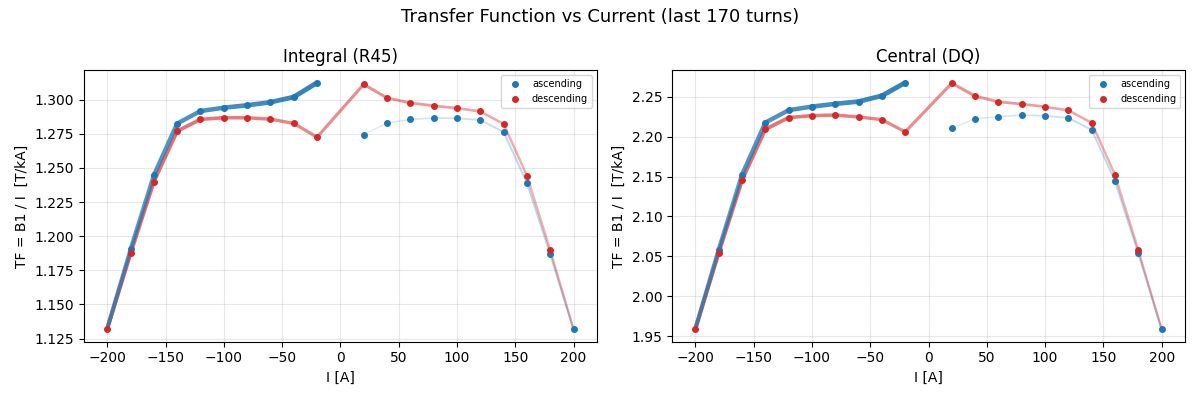

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "TF")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("TF = B1 / I  [T/kA]")
    ax.set_title(label)
    ax.legend(fontsize=7)

fig.suptitle(f"Transfer Function vs Current (last {N_LAST_TURNS} turns)",
             fontsize=13)
fig.tight_layout()
plt.show()

## Harmonic hysteresis — excluding I ≈ 0 A plateaus

At I = 0 the relative harmonics (bn = Bn/B1) blow up because B1 → 0.
The plots below exclude |I_nom| ≤ 2 A to show the physical hysteresis.

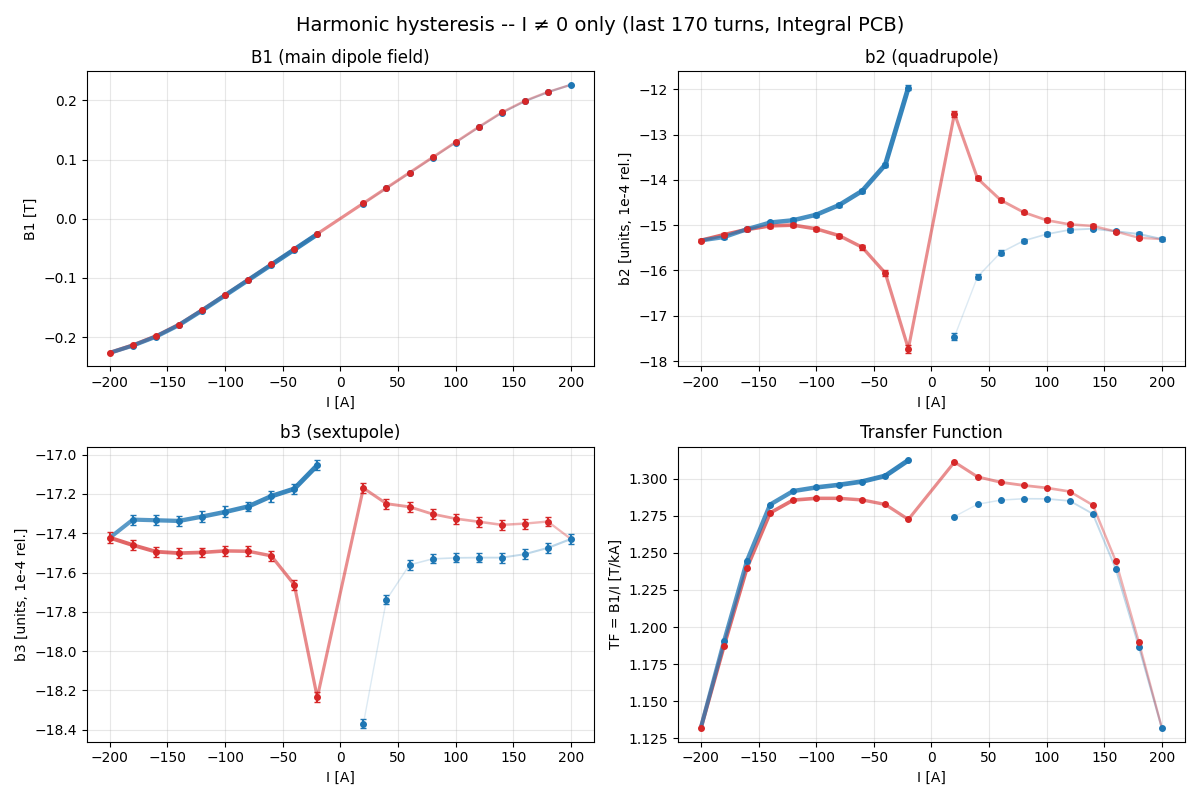

In [16]:
# ── Zoomed hysteresis: exclude I ≈ 0 A plateaus ──
mask_nz = summ_int["I_nom"].abs() > 2.0
summ_nz = summ_int[mask_nz].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_hysteresis(axes[0, 0], summ_nz, "I_nom", "B1_mean", "B1_std")
axes[0, 0].set_xlabel("I [A]")
axes[0, 0].set_ylabel("B1 [T]")
axes[0, 0].set_title("B1 (main dipole field)")

plot_hysteresis(axes[0, 1], summ_nz, "I_nom", "b2_units_mean", "b2_units_std")
axes[0, 1].set_xlabel("I [A]")
axes[0, 1].set_ylabel("b2 [units, 1e-4 rel.]")
axes[0, 1].set_title("b2 (quadrupole)")

plot_hysteresis(axes[1, 0], summ_nz, "I_nom", "b3_units_mean", "b3_units_std")
axes[1, 0].set_xlabel("I [A]")
axes[1, 0].set_ylabel("b3 [units, 1e-4 rel.]")
axes[1, 0].set_title("b3 (sextupole)")

plot_hysteresis(axes[1, 1], summ_nz, "I_nom", "TF")
axes[1, 1].set_xlabel("I [A]")
axes[1, 1].set_ylabel("TF = B1/I [T/kA]")
axes[1, 1].set_title("Transfer Function")

fig.suptitle(f"Harmonic hysteresis -- I ≠ 0 only (last {N_LAST_TURNS} turns, Integral PCB)",
             fontsize=14)
fig.tight_layout()
plt.show()

## 11. Multipole Spectrum at Peak Current

Bar chart of normal (bn) and skew (an) harmonics at the
highest-current good plateau.

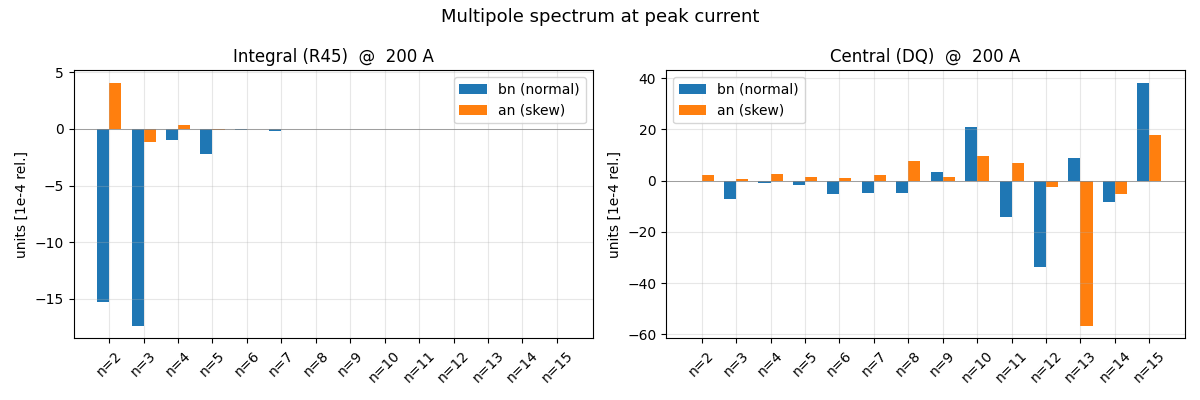

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    good = summ[summ["quality"] == "good"]
    if good.empty:
        ax.set_title(f"{label}: no valid data")
        continue
    peak = good.loc[good["I_nom"].abs().idxmax()]

    orders, bn, an = [], [], []
    for n in range(2, 16):
        bc = f"b{n}_units_mean"
        ac = f"a{n}_units_mean"
        if bc in summ.columns and pd.notna(peak.get(bc)):
            orders.append(n)
            bn.append(peak[bc])
            an.append(peak.get(ac, 0.0) if pd.notna(peak.get(ac)) else 0.0)

    if orders:
        x = np.arange(len(orders))
        w = 0.35
        ax.bar(x - w / 2, bn, w, label="bn (normal)", color="tab:blue")
        ax.bar(x + w / 2, an, w, label="an (skew)", color="tab:orange")
        ax.set_xticks(x)
        ax.set_xticklabels([f"n={o}" for o in orders], rotation=45)
        ax.set_ylabel("units [1e-4 rel.]")
        ax.set_title(f"{label}  @  {peak['I_nom']:.0f} A")
        ax.legend()
        ax.axhline(0, color="gray", lw=0.5)

fig.suptitle("Multipole spectrum at peak current", fontsize=13)
fig.tight_layout()
plt.show()

## 12. Summary Table

In [18]:
def format_summary(summ, label):
    print(f"\n{'=' * 85}")
    print(f"  {label}")
    print(f"  R_ref = {R_REF*1e3:.1f} mm  |  "
          f"last {N_LAST_TURNS} turns averaged")
    print(f"{'=' * 85}")
    hdr = (f"{'Run':>4s} {'I [A]':>8s} {'Branch':>10s} "
           f"{'B1 [T]':>12s} {'b2 [units]':>12s} "
           f"{'b3 [units]':>12s} {'TF [T/kA]':>10s} {'Qual':>5s}")
    print(hdr)
    print("-" * 85)
    for _, r in summ.iterrows():
        b1 = f"{r['B1_mean']:.6f}" if pd.notna(r['B1_mean']) else "---"
        b2 = (f"{r.get('b2_units_mean', np.nan):.2f}"
              if pd.notna(r.get('b2_units_mean')) else "---")
        b3 = (f"{r.get('b3_units_mean', np.nan):.2f}"
              if pd.notna(r.get('b3_units_mean')) else "---")
        tf = f"{r['TF']:.4f}" if pd.notna(r['TF']) else "---"
        print(f"{r['run_id']:4.0f} {r['I_nom']:+8.1f} "
              f"{r['branch']:>10s} {b1:>12s} {b2:>12s} "
              f"{b3:>12s} {tf:>10s} {r['quality']:>5s}")

format_summary(summ_int, "Integral PCB (R45)")
format_summary(summ_cen, "Central PCB (DQ)")


  Integral PCB (R45)
  R_ref = 33.0 mm  |  last 170 turns averaged
 Run    I [A]     Branch       B1 [T]   b2 [units]   b3 [units]  TF [T/kA]  Qual
-------------------------------------------------------------------------------------
   0     +0.0  ascending    -0.000263       165.34        46.98        ---  good
   1    +20.0  ascending     0.025489       -17.46       -18.37     1.2745  good
   2    +40.0  ascending     0.051311       -16.14       -17.74     1.2828  good
   3    +60.0  ascending     0.077131       -15.61       -17.56     1.2855  good
   4    +80.0  ascending     0.102920       -15.34       -17.53     1.2865  good
   5   +100.0  ascending     0.128640       -15.20       -17.53     1.2864  good
   6   +120.0  ascending     0.154206       -15.10       -17.52     1.2851  good
   7   +140.0  ascending     0.178683       -15.08       -17.52     1.2763  good
   8   +160.0  ascending     0.198255       -15.14       -17.51     1.2391  good
   9   +180.0  ascending     0.21363

## 13. Export to CSV (optional)

In [19]:
# Uncomment to save:
# out = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer\output")
# out.mkdir(exist_ok=True)
# summ_int.to_csv(out / "MC62_02_staircase_without_shims_integral_summary.csv", index=False)
# summ_cen.to_csv(out / "MC62_02_staircase_without_shims_central_summary.csv", index=False)
# df_int.to_csv(out / "MC62_02_staircase_without_shims_integral_all_turns.csv", index=False)
# df_cen.to_csv(out / "MC62_02_staircase_without_shims_central_all_turns.csv", index=False)
# print("Saved to", out)

## Analysis Choices Summary

Key parameters used in this analysis, for reproducibility and cross-comparison.

In [20]:
_cel_fed_int = diag_int.recommendation if "diag_int" in dir() else "N/A"
_cel_fed_cen = diag_cen.recommendation if "diag_cen" in dir() else "N/A"

choices = pd.DataFrame({
    "Parameter": [
        "Samples/turn",
        "Rotation speed",
        "Turns/plateau",
        "N_LAST_TURNS (settled)",
        "N_SKIP_END",
        "Pipeline OPTIONS",
        "cel/fed diagnostic (Integral)",
        "cel/fed diagnostic (Central)",
        "DRIFT_MODE",
        "R_REF (m)",
        "MAGNET_ORDER",
        "FLIP_FIELD_SIGN",
        "MIN_B1_T (ok_main threshold)",
    ],
    "Value": [
        str(SAMPLES_PER_TURN),
        "60 rpm (1 Hz, from measurement metadata)",
        "350",
        str(N_LAST_TURNS),
        "0 (default)",
        str(OPTIONS),
        _cel_fed_int,
        _cel_fed_cen,
        DRIFT_MODE,
        str(R_REF),
        f"{MAGNET_ORDER} (dipole)",
        str(FLIP_FIELD_SIGN),
        str(MIN_B1_T),
    ],
})

choices.style.hide(axis="index")

Parameter,Value
Samples/turn,1024
Rotation speed,"60 rpm (1 Hz, from measurement metadata)"
Turns/plateau,350
N_LAST_TURNS (settled),170
N_SKIP_END,0 (default)
Pipeline OPTIONS,"('dri', 'rot')"
cel/fed diagnostic (Integral),UNSAFE
cel/fed diagnostic (Central),UNSAFE
DRIFT_MODE,legacy
R_REF (m),0.033
